# 12 — MFD with donor excitation only

One laser, four detectors, and **only the labelled sample**. This is the
commonest single-molecule FRET measurement and it is the hardest case for this
model, because there is no donor-only reference: the donor's unquenched
lifetime spectrum has to come out of the same four histograms that carry the
distance, and the acceptor's own decay has to come out of the sensitised
emission alone.

Read `11_configuring_the_network.ipynb` first for what a description is.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import experiment as X
from bd import P                      # the prototype, for the measured deviance reference


## The description


In [2]:
exp = X.mfd_donor_excitation()
print(exp.summary())


MFD, donor excitation only: 4 histograms
  samples     DA (donor+acceptor)
  excitations green at 0 ns, reaches donor x 1.0, acceptor x EX_AG
  detectors   gv (green), gh (green), rv (red), rh (red)
  histograms
    DA  gv_vv    parallel      donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  gh_vh    perpendicular donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  rv_vv    parallel      donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  rh_vh    perpendicular donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
  no donor-only and no acceptor-only reference: see the identifiability table


The same description as JSON — this is what you would keep beside the data, and
what a program other than this notebook would read.


In [3]:
print(exp.to_json()[:700] + '\n...')
assert X.Experiment.from_json(exp.to_json()).to_dict() == exp.to_dict()


{
  "name": "MFD, donor excitation only",
  "notes": "no donor-only and no acceptor-only reference: see the identifiability table",
  "interleaved": false,
  "samples": [
    {
      "name": "DA",
      "carries": [
        "donor",
        "acceptor"
      ]
    }
  ],
  "excitations": [
    {
      "name": "green",
      "excites": {
        "donor": 1.0,
        "acceptor": "EX_AG"
      },
      "delay_ns": 0.0
    }
  ],
  "detectors": [
    {
      "name": "gv",
      "colour": "green"
    },
    {
      "name": "gh",
      "colour": "green"
    },
    {
      "name": "rv",
      "colour": "red"
    },
    {
      "name": "rh",
      "colour": "red"
    }
  ],
  "channels": [
    {
   
...


## What this experiment can and cannot determine

Before fitting anything. Each unknown is moved and the change in every
histogram measured; the share is how much of what the posterior will say comes
from the data rather than from the prior. **A share near zero is conclusive**:
nothing in the data moves, so whatever the fit prints for it is the prior. A
share near one is not conclusive — this is the diagonal, and a coordinate can
still be undetermined through a correlation.


In [4]:
model = X.build(exp, knots=25)
rows = X.identifiability(exp, model)
print(f'{"unknown":<16}{"group":<7}{"data share":>11}   carried by')
for r in sorted(rows, key=lambda r: r['data_share'])[:12]:
    print(f'{r["variable"]:<16}{r["role"]:<7}{r["data_share"]:>11.4f}   {r["carried_by"]}')
blind = X.unidentified(rows)
print(f'\n{len(blind)} of {len(rows)} unknowns are moved by nothing in these data:')
print('  ' + ', '.join(r['variable'] for r in blind))


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt


unknown         group   data share   carried by
log10_lam       hyper       0.0000   nothing
r0_a            phys        0.8730   DA rv_vv, DA rh_vh
l1              cal         0.9123   DA gv_vv, DA rv_vv
r0_d            phys        0.9306   DA gv_vv, DA gh_vh, DA rv_vv
l2              cal         0.9505   DA gh_vh, DA rh_vh
w_rho_a         phys        0.9721   DA rv_vv, DA rh_vh
C_GA            cal         0.9728   DA gv_vv, DA gh_vh
w_rho           phys        0.9917   DA gv_vv, DA gh_vh
bkg_DA_gh_vh    inst        0.9941   DA gh_vh
C_RA            cal         0.9950   DA rv_vv, DA rh_vh
C_GD            cal         0.9958   DA gv_vv, DA gh_vh
c               phys        0.9966   DA rv_vv, DA rh_vh, DA gv_vv

1 of 34 unknowns are moved by nothing in these data:
  log10_lam


## Data from that description

A mixture of two populations, one at $R/R_0 = 0.85$ and a broader one at 1.25,
simulated through the same forward model the fit uses and given Poisson noise.
No bursts and no selection: this is the idealised measurement, so that anything
the fit gets wrong is the *inference's* fault and not the experiment's.


In [5]:
rel = model['rel']
p_true = (np.exp(-0.5 * ((rel - 0.85) / 0.07) ** 2)
          + 0.6 * np.exp(-0.5 * ((rel - 1.25) / 0.09) ** 2))
p_true = p_true / p_true.sum()
y, lam_true, vals = X.simulate(exp, model, p_true, photons=3e5, seed=1)
for k in model['keys']:
    print(f'{k[0]:<3} {k[1]:<8} {float(y[k].sum()):>10,.0f} photons')


DA  gv_vv       308,899 photons
DA  gh_vh       197,360 photons
DA  rv_vv       299,093 photons
DA  rh_vh       241,439 photons


## The fit

The roughness weight of the P-spline prior on $\log p(R/R_0)$ is not maximised
but integrated out: a Laplace approximation at each node of a grid, the nodes
mixed by their evidences.


In [6]:
import time
t0 = time.time()
g, post = X.fit(exp, model, y, lam_nodes=(1.0, 0.0, -1.0))
print(f'{time.time() - t0:.0f} s')


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


49 s


## Rule 0

No number about a fitted quantity is reportable without the weighted residuals
and the fit statistic. The Poisson deviance per degree of freedom is compared
with a **measured** reference and not with 1: the deviance of a correct model
at these counts is close to the number of *bins*, while the reported degrees of
freedom subtract the whole parameter dimension even though a penalised spline
uses far fewer of them. So the reference is Poisson draws at the fitted means.


In [7]:
ref_mean, ref_sd = P.poisson_reference(post, n_draw=200, seed=0)
print(f'{"histogram":<14}{"photons":>12}{"D/dof":>9}{"runs p":>9}')
for r in X.rule0(model, g, post, y):
    print(f'{r["channel"]:<14}{r["counts"]:>12,.0f}{r["dpd"]:>9.3f}{r["runs_p"]:>9.3f}')
z = (post['dev'] / post['dof'] - ref_mean) / ref_sd
print(f'\nreference D/dof (Poisson draws at the fitted means): {ref_mean:.3f} +- {ref_sd:.3f}')
print(f'this fit: {post["dev"] / post["dof"]:.3f}, which is {z:+.1f} reference sd')
print('VERDICT:', 'passes' if abs(z) < 3 else 'FAILS -- this result is excluded and counted')


histogram          photons    D/dof   runs p
DA gv_vv           308,899    0.984    0.937
DA gh_vh           197,360    1.226    0.099
DA rv_vv           299,093    1.197    0.852
DA rh_vh           241,439    1.195    0.481
all              1,046,791    1.151      nan

reference D/dof (Poisson draws at the fitted means): 1.247 +- 0.079
this fit: 1.151, which is -1.2 reference sd
VERDICT: passes


In [8]:
ks = list(g.data_keys)
n = len(ks)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 5.0), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 1.0]))
axes = np.atleast_2d(axes).reshape(2, n)
tc = model['Eu']['tc']; wid = model['Eu']['wid']
for j, k in enumerate(ks):
    a, ar = axes[0, j], axes[1, j]
    yk = np.asarray(y[k]); lk = np.asarray(post['lam'][k])
    a.semilogy(tc, np.maximum(yk, 0.3) / wid, 'k.', ms=2, label='data')
    a.semilogy(tc, np.clip(lk, 1e-3, None) / wid, 'C3-', lw=1.0, label='fit')
    r = post['rows'][k]
    a.set_title(f'{k[0]} {k[1]}\nD/dof {r["dpd"]:.3f}, runs p {r["runs_p"]:.2f}', fontsize=9)
    if j == 0:
        a.set_ylabel('counts per ns'); a.legend(fontsize=8)
    ar.plot(tc, r['w'], lw=0.6, color='C3'); ar.axhline(0, color='k', lw=0.5)
    ar.set_ylim(-5.5, 5.5); ar.set_xlabel('time / ns')
    if j == 0:
        ar.set_ylabel('weighted residual')
fig.tight_layout(); plt.show()


/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_19341/2086981411.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## What came back

The posterior over the distance distribution, with the band the delta method
gives, against the truth it was simulated from.


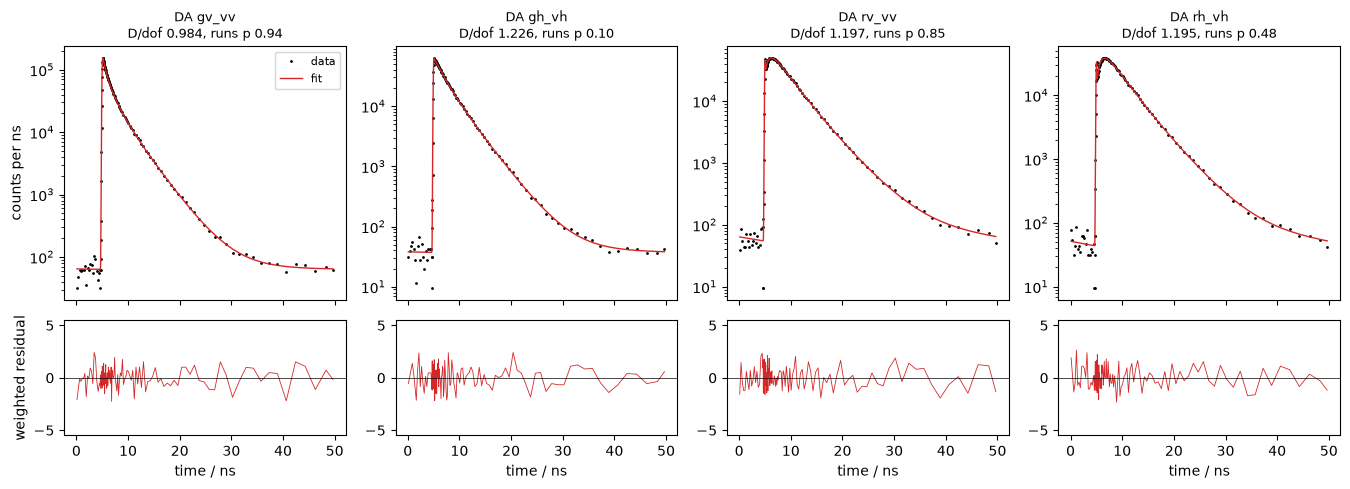

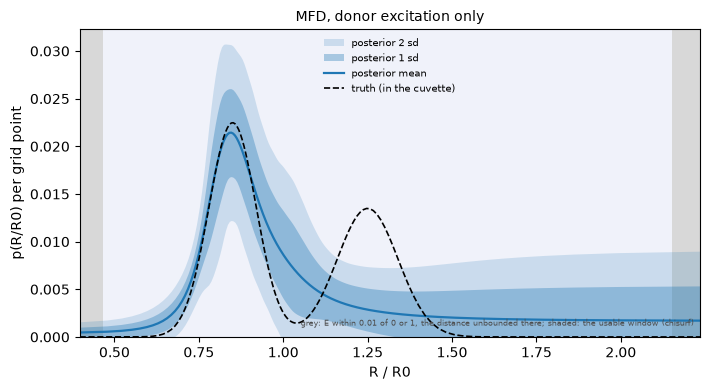

mean R/R0:  truth 0.9746   posterior 0.9394
the evidence mixture put weights [0.0005 0.0014 0.0036 0.008  0.016  0.0299 0.0532 0.0888 0.1359 0.1832
 0.2046 0.1741 0.1009] on log10 lambda = [-1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]


In [9]:
fig = P.plot_pR(model, post, p_true=p_true, title=exp.name)
plt.show()
m, lo1, hi1, lo2, hi2 = model['L'].delta_bands(None, post, rel, space='linear')
mean_true = float((p_true * rel).sum()); mean_fit = float((m * rel).sum())
print(f'mean R/R0:  truth {mean_true:.4f}   posterior {mean_fit:.4f}')
print(f'the evidence mixture put weights {np.round(post["weights"], 4)} on '
      f'log10 lambda = {post["lam_nodes"]}')


## What this geometry costs

The description named no donor-only and no acceptor-only reference, and the
identifiability table above says what that costs before the fit is run. The fit
still lands on the truth here, on data simulated from the very model being
fitted and with a million photons -- which is the friendliest possible test, and
worth remembering when reading the band.

Two things to take from this notebook rather than from the numbers:

* the description is four lines longer than the difference between this
  experiment and the one in notebook 14, and nothing else changed;
* the identifiability table is a property of the *description*, so it can be
  read before the sample is even prepared.
